# Статистическая проверка различий в retention

## Цель исследования

Проверить, являются ли различия в удержании пользователей между каналами привлечения **ads** и **referral** статистически значимыми.

---

## Гипотезы

**H₀:** средний retention пользователей из каналов **ads** и **referral** не различается.

**H₁:** средний retention пользователей различается.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind

## Загрузка данных

Используются результаты когортного анализа retention, рассчитанные средствами SQL.

Каждая строка соответствует одной когорте пользователей.

In [5]:
df = pd.read_csv("../data/retention_cohorts.csv")

df.head()

,acquisition_channel,registration_date,days_since_registration,retention
0,ads,2023-01-01,1,23.200
1,ads,2023-01-01,3,21.600
2,ads,2023-01-01,7,10.400
3,ads,2023-01-01,14,2.400
4,ads,2023-01-02,1,24.615


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   acquisition_channel      2518 non-null   object 
 1   registration_date        2518 non-null   object 
 2   days_since_registration  2518 non-null   int64  
 3   retention                2518 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 78.8+ KB


## Проверка статистических гипотез

Для каждого контрольного дня сравнивается retention пользователей,
привлечённых через каналы **ads** и **referral**.

Используется t-критерий Уэлча (`equal_var=False`),
который не требует предположения о равенстве дисперсий.

In [9]:
days = [1, 3, 7, 14, 30]

alpha = 0.05

results = []

In [10]:
for day in days:

    subset = df[df["days_since_registration"] == day]

    ads = subset[
        subset["acquisition_channel"] == "ads"
    ]["retention"]

    referral = subset[
        subset["acquisition_channel"] == "referral"
    ]["retention"]

    if len(ads) < 2 or len(referral) < 2:
        continue

    statistic, p_value = ttest_ind(
        ads,
        referral,
        equal_var=False
    )

    results.append(
        {
            "day": day,
            "t_statistic": round(statistic, 3),
            "p_value": p_value,
            "significant": p_value < alpha
        }
    )

In [11]:
results_df = pd.DataFrame(results)

results_df["p_value"] = results_df["p_value"].round(10)

results_df

,day,t_statistic,p_value,significant
0,1,-13.006,0.0,True
1,3,-10.034,0.0,True
2,7,-41.745,0.0,True
3,14,-57.437,0.0,True


## Визуализация

Сравним распределение retention между каналами
на 7-й день после регистрации.

In [12]:
day7 = df[df["days_since_registration"] == 7]

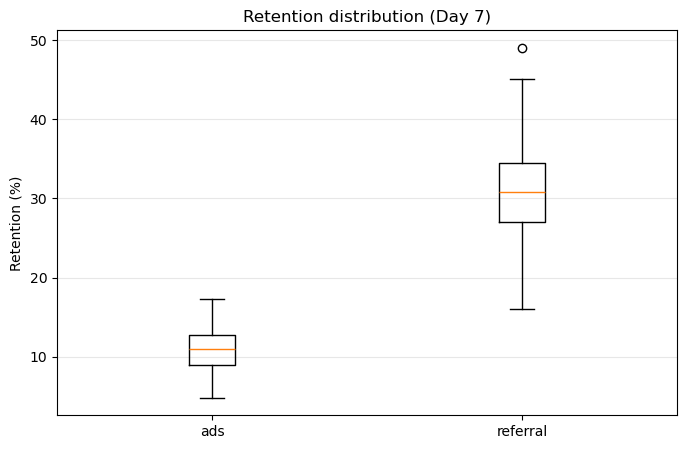

In [14]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        day7.loc[
            day7["acquisition_channel"] == "ads",
            "retention"
        ],
        day7.loc[
            day7["acquisition_channel"] == "referral",
            "retention"
        ]
    ],
    tick_labels=["ads", "referral"]
)

plt.title("Retention distribution (Day 7)")
plt.ylabel("Retention (%)")

plt.grid(axis="y", alpha=0.3)

plt.show()

# Вывод

Статистическая проверка показала, что различия в удержании пользователей между каналами **ads** и **referral** являются статистически значимыми на всех исследуемых этапах жизненного цикла пользователя (p-value < 0.05).

Это означает, что наблюдаемые различия в retention с высокой вероятностью не являются следствием случайных колебаний данных.

Полученные результаты подтверждают выводы когортного анализа: пользователи, привлечённые через канал **referral**, демонстрируют более высокое удержание по сравнению с пользователями из **ads**.

В сочетании с результатами анализа поведения пользователей и расчётом unit-экономики можно сделать вывод, что канал **ads** привлекает менее вовлечённую аудиторию, что приводит к более низкому retention и ухудшению финансовых показателей.

Полученные результаты свидетельствуют о необходимости дополнительного анализа качества рекламного трафика, процесса onboarding и эффективности маркетинговых кампаний для канала **ads**.